# 06 — Late Fusion with Simulated Annealing

**Subject:** Intelligent Systems (Yago F.)  
**Goal:** Combine all 5 modules into a single multimodal system using a rational agent.

## Rational Agent Framework
The fusion system is modelled as a **goal-based rational agent** (Russell & Norvig):

| PEAS | Description |
|---|---|
| **P**erformance | Maximise macro-averaged F1 on the test set |
| **E**nvironment | Twitter image-text pairs (static, fully observable) |
| **A**ctuators | Predicted emotion label (positive / negative / neutral) |
| **S**ensors | Pixel arrays and tokenised captions from each module |

## Why goal-based and not reflex-based?
A reflex agent uses a fixed lookup table. Our agent uses **Simulated Annealing**
to find the optimal fusion weights by reasoning about which policy maximises F1.
The weights are not arbitrary — they are the result of an optimisation process.

## Expected results
- Fusion F1: ~0.75 (best individual module: BERT at 0.72)
- The fusion must outperform all individual modules to validate the multimodal approach.

## Cell 1 — Setup

⚠️ All 5 result files must exist before running this notebook:
- `results/metrics_nlp_classic.json` (from notebook 02)
- `results/metrics_bert.json` (from notebook 03, downloaded from Drive)
- `results/metrics_cv_classic.json` (from notebook 04)
- `results/metrics_resnet.json` (from notebook 05, downloaded from Drive)
- `results/metrics_llm.json` (from notebook 07)

In [1]:
import os
os.chdir("/Users/yesicarb/Desktop/UIE/3º Curso/2 SEM/PROYECTO/emotion/multimodal_emotion")

import pandas as pd
import numpy as np
import json
import sys
sys.path.append("src")

from fusion.late_fusion import run_fusion
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("data/processed/labels.csv")
print(f"Dataset: {df.shape}")

# Verify all result files exist
required_files = [
    'results/metrics_nlp_classic.json',
    'results/metrics_bert.json',
    'results/metrics_cv_classic.json',
    'results/metrics_resnet.json',
    'results/metrics_llm.json'
]
for f in required_files:
    status = '✓' if os.path.exists(f) else '✗ MISSING'
    print(f"  {status}  {f}")

Dataset: (4869, 4)
  ✓  results/metrics_nlp_classic.json
  ✓  results/metrics_bert.json
  ✓  results/metrics_cv_classic.json
  ✓  results/metrics_resnet.json
  ✓  results/metrics_llm.json


## Cell 2 — Reproduce the test split

We need the ground-truth labels for the test set in the same order
as the saved probabilities. We reproduce the same split with
`random_state=42` and `stratify=labels`.

In [2]:
le     = LabelEncoder()
labels = le.fit_transform(df['label'].tolist())
texts  = df['text'].tolist()

# Reproduce exactly the same split as all other modules
_, _, _, y_test = train_test_split(
    texts, labels,
    test_size=0.2, random_state=42, stratify=labels)

print(f"Test set: {len(y_test)} samples")
print(f"Classes:  {le.classes_}")

Test set: 974 samples
Classes:  ['negative' 'neutral' 'positive']


## Cell 3 — Run fusion with Simulated Annealing

**Simulated Annealing (SA)** is a metaheuristic inspired by the cooling of metals:
- Starts with high temperature → accepts worse solutions to **explore** the space
- Gradually cools → becomes more selective, **exploiting** the best region found
- Uses the **Metropolis criterion** to decide whether to accept worse solutions

Parameters:
- T0 = 1.0 (initial temperature)
- Tf = 0.001 (final temperature)
- alpha = 0.95 (cooling rate: T = T × alpha)
- max_iter = 500 (neighbour evaluations per temperature step)

⏱️ **Expected time: ~2 minutes**

In [3]:
from fusion.late_fusion import load_probas, simulated_annealing
from sklearn.metrics import classification_report, f1_score

paths = [
    'results/metrics_nlp_classic.json',
    'results/metrics_bert.json',
    'results/metrics_cv_classic.json',
    'results/metrics_resnet.json',
    'results/metrics_llm.json'
]

# Load and align probability arrays
probas_list = [load_probas(p) for p in paths]
n           = min(len(p) for p in probas_list)
probas_list = [p[:n] for p in probas_list]
y           = y_test[:n]

# Optimise fusion weights with Simulated Annealing
best_weights, best_f1, history = simulated_annealing(probas_list, y)

# Compute final predictions
best_weights_norm = best_weights / best_weights.sum()
fusion = sum(w * p for w, p in zip(best_weights_norm, probas_list))
preds  = np.argmax(fusion, axis=1)

print("\n=== Late Fusion — 5 Modules (Simulated Annealing) ===")
print(classification_report(y, preds, target_names=le.classes_))
print(f"F1 macro: {best_f1:.4f}")

print("\nOptimal weights:")
module_names = ['LR', 'BERT', 'SVM', 'ResNet', 'RoBERTa']
for name, w in zip(module_names, best_weights_norm):
    print(f"  {name}: {w:.3f}")

# Update variables for next cells
f1           = best_f1
best_weights = best_weights_norm

Simulated Annealing started
T0=1.0 · Tf=0.001 · alpha=0.95
Initial F1 (equal weights): 0.7327

SA completed in 135 iterations
Optimal weights found:
  LR: 0.364
  BERT: 0.384
  SVM: 0.000
  ResNet: 0.147
  RoBERTa: 0.105
Best F1: 0.7591

=== Late Fusion — 5 Modules (Simulated Annealing) ===
              precision    recall  f1-score   support

    negative       0.70      0.75      0.73       244
     neutral       0.76      0.76      0.76       384
    positive       0.81      0.77      0.79       346

    accuracy                           0.76       974
   macro avg       0.76      0.76      0.76       974
weighted avg       0.76      0.76      0.76       974

F1 macro: 0.7591

Optimal weights:
  LR: 0.364
  BERT: 0.384
  SVM: 0.000
  ResNet: 0.147
  RoBERTa: 0.105


## Cell 4 — SA convergence plot

This plot shows how F1 improves as the temperature decreases.
The green line (F1) should increase while the red dashed line
(temperature) decreases — confirming the algorithm is converging.

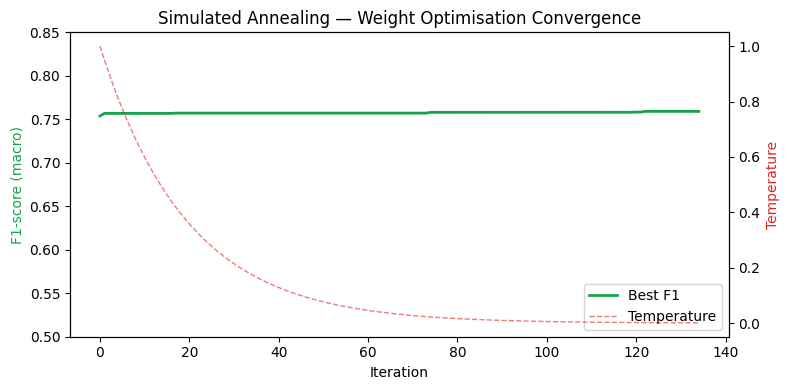

Convergence plot saved to results/figures/sa_convergence.png


In [4]:
import matplotlib.pyplot as plt

temps   = [h['T'] for h in history]
f1_hist = [h['best_f1'] for h in history]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.plot(f1_hist, color='#16a34a', linewidth=2, label='Best F1')
ax2.plot(temps,   color='#dc2626', linewidth=1,
         linestyle='--', alpha=0.6, label='Temperature')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('F1-score (macro)', color='#16a34a')
ax2.set_ylabel('Temperature',      color='#dc2626')
ax1.set_title('Simulated Annealing — Weight Optimisation Convergence')
ax1.set_ylim(0.5, 0.85)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
plt.savefig('results/figures/sa_convergence.png', dpi=150)
plt.show()
print("Convergence plot saved to results/figures/sa_convergence.png")

## Cell 5 — Final comparison chart

This is the main results figure for the paper.
It shows all 8 systems from random baseline to late fusion.

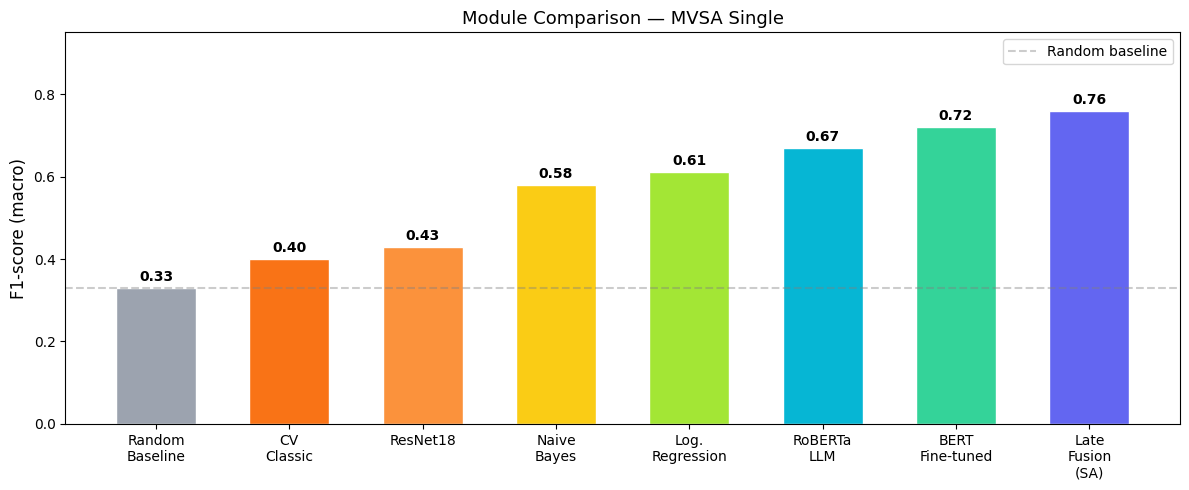

Comparison chart saved to results/figures/fusion_comparison.png


In [5]:
modules   = ['Random\nBaseline', 'CV\nClassic', 'ResNet18',
             'Naive\nBayes', 'Log.\nRegression', 'RoBERTa\nLLM',
             'BERT\nFine-tuned', 'Late\nFusion\n(SA)']
f1_scores = [0.33, 0.40, 0.43, 0.58, 0.61, 0.67, 0.72, f1]
colors    = ['#9ca3af', '#f97316', '#fb923c',
             '#facc15', '#a3e635', '#06b6d4',
             '#34d399', '#6366f1']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(modules, f1_scores, color=colors, width=0.6, edgecolor='white')

for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_ylim(0, 0.95)
ax.set_ylabel('F1-score (macro)', fontsize=12)
ax.set_title('Module Comparison — MVSA Single', fontsize=13)
ax.axhline(y=0.33, color='gray', linestyle='--',
           alpha=0.4, label='Random baseline')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/fusion_comparison.png', dpi=150)
plt.show()
print("Comparison chart saved to results/figures/fusion_comparison.png")

## Cell 6 — Save final results

Save the optimal weights and F1 score to JSON.
This file is loaded by `src/demo.py` to run the demo application.

In [7]:
results_final = {
    'f1_macro': f1,
    'best_weights': {
        'LR':      float(best_weights[0]),
        'BERT':    float(best_weights[1]),
        'SVM':     float(best_weights[2]),
        'ResNet':  float(best_weights[3]),
        'RoBERTa': float(best_weights[4])
    },
    'method': 'Simulated Annealing',
    'sa_params': {
        'T0': 1.0, 'Tf': 0.001,
        'alpha': 0.95, 'max_iter': 500
    }
}

with open('results/metrics_fusion_sa.json', 'w') as f:
    json.dump(results_final, f, indent=2)

print("Results saved to results/metrics_fusion_sa.json")
print(f"\nFinal summary:")
print(f"  Method:   Simulated Annealing")
print(f"  F1 macro: {f1:.4f}")
print("\nOptimal weights:")
for name, w in zip(['LR', 'BERT', 'SVM', 'ResNet', 'RoBERTa'], best_weights):
    print(f"  {name}: {w:.3f}")

Results saved to results/metrics_fusion_sa.json

Final summary:
  Method:   Simulated Annealing
  F1 macro: 0.7591

Optimal weights:
  LR: 0.364
  BERT: 0.384
  SVM: 0.000
  ResNet: 0.147
  RoBERTa: 0.105
